# 0. Sobre

## 0.1 Dicionário de Dados

* **customer_id**: Identificador único do cliente.
* **order_id**: Identificador único do pedido.
* **customer_age**: Idade do cliente.
* **customer_region**: Região geográfica do cliente.
* **customer_tenure_months**: Tempo de relacionamento do cliente com a
empresa (em meses).
* **order_value**: Valor total do pedido.
* **items_quantity**: Quantidade de itens no pedido.
* **discount_value**: Valor de desconto aplicado ao pedido.
* **payment_installments**: Número de parcelas do pagamento.
* **delivery_time_days**: Tempo total de entrega (em dias).
* **delivery_delay_days**: Quantidade de dias de atraso na entrega.
* **freight_value**: Valor do frete.
* **delivery_attempts**: Número de tentativas de entrega.
* **customer_service_contacts**: Número de contatos do cliente com o
atendimento.
* **resolution_time_days**: Tempo para resolução de problemas (em dias).
* **complaints_count**: Número de reclamações registradas pelo cliente.
* **repeat_purchase_30d**: Indica se houve recompra em até 30 dias após o
pedido (0 = não, 1 = sim).
* **csat_internal_score**: Score interno de satisfação do cliente.
* **nps_score**: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.

## 0.2 Perguntas Norteadoras
* Quais fatores parecem mais críticos para a satisfação?
* O que mais gera detratores?
* Existe algum “ponto de ruptura” na experiência do cliente?
* Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

# 1. Configuração e importação de bibliotecas

In [43]:
# Manipulação de Dados

import pandas as pd
import numpy as np

# Gráficos

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configurações

import warnings
warnings.filterwarnings("ignore")

# 2. Carga e Inspeção dos Dados
- Qual a quantidade de linhas e colunas do dataset?
- Quais os tipos das colunas?



In [44]:
# Leitura d Arquivo .csv

df_nps = pd.read_csv('../data/desafio_nps_fase_1.csv')

# Conferindo as 5 primeiras linhas do DataFrame

df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [45]:
# Quantidade de linhas e Colunas  no Dataset

print(f"Número de linhas: {df_nps.shape[0]}")
print(f"Número de colunas: {df_nps.shape[1]}")

Número de linhas: 2500
Número de colunas: 19


In [46]:
# Mostrando o tipo de dado de cada coluna no dataset

df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

# 3. Qualidade dos dados

In [47]:
# Verificando se existem registros nulos

print(f"Quantidade de valores nulos: {df_nps.isnull().sum().sum()}")

Quantidade de valores nulos: 0


In [48]:
# Quantidade de valores duplicados

print(f"Quantidade de valores duplicados: {df_nps.duplicated().sum()}")

Quantidade de valores duplicados: 0


## 3.1 Validação de regras de negócio e anomalias

In [49]:
# Count, média, desvio padrão, min e percentis das colunas de valores.

df_nps[['customer_age','customer_tenure_months','order_value','items_quantity','discount_value',
        'payment_installments','delivery_time_days','delivery_delay_days','freight_value',
        'delivery_attempts','customer_service_contacts','resolution_time_days','nps_score','repeat_purchase_30d','complaints_count',
        'csat_internal_score']].describe().round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [50]:
# Valor mínimo e valor máxixo de cada coluna de valores

df_nps[['customer_age','customer_tenure_months','order_value','items_quantity','discount_value',
        'payment_installments','delivery_time_days','delivery_delay_days','freight_value',
        'delivery_attempts','customer_service_contacts','resolution_time_days','nps_score','repeat_purchase_30d','complaints_count',
        'csat_internal_score']].agg(['min','max']).round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
min,18,1,7.76,1,0.02,1,2,0,2.62,1,0,0,0.0,0,0,0.0
max,69,119,1983.81,6,230.33,11,14,8,76.13,3,7,11,10.0,1,11,10.0


## 3.2 Novas Colunas

### 3.2.1 Classificação NPS
* (Notas 9 e 10): Clientes extremamente satisfeitos que divulgam a marca e geram crescimento orgânico: Promotor.
* (Notas 7 e 8): Clientes apenas satisfeitos, mas que não são leais e podem migrar facilmente para a concorrência: Neutro.
* (Notas 0 a 6): Clientes insatisfeitos que tiveram experiências ruins e podem prejudicar a reputação da empresa: Detrator.

In [51]:
# Criação de nova coluna com os rótulos de classificação do NPS

conditions = [
    (df_nps['nps_score'].round(0) >= 9),
    (df_nps['nps_score'].round(0) >= 7) & (df_nps['nps_score'].round(0) <= 8),
    (df_nps['nps_score'].round(0) >= 0) & (df_nps['nps_score'].round(0) <= 6)
]

# Classificação do NPS em Promotor, Neutro e Detrator

choices = ['Promotor', 'Neutro', 'Detrator']
df_nps['nps_classification'] = np.select(conditions, choices, default='Não Classificado')

In [52]:
# Visualização da nova coluna criada e seus valores

df_nps['nps_classification'].value_counts()

nps_classification
Detrator    2001
Neutro       351
Promotor     148
Name: count, dtype: int64

### 3.2.2 Porcentagem de Desconto

In [53]:
# Verificando se tem valores que receberam desconto

df_nps['discount_value'][df_nps['discount_value'] > 0]

0       39.35
1        9.51
2       42.82
3       19.58
4       29.37
        ...  
2495    11.41
2496    36.44
2497     4.84
2498     2.11
2499    16.51
Name: discount_value, Length: 2500, dtype: float64

In [54]:
# Calculando a porcentagem de desconto

df_nps['discount_percent'] = (df_nps['discount_value'] / df_nps['order_value'] * 100).round(2)

df_nps['discount_percent'].head()

0    28.16
1     2.07
2     8.44
3     6.48
4    11.61
Name: discount_percent, dtype: float64

### 3.2.3 Entrega Atrasada

In [55]:
# Verificando casos de entrega atrasada

df_nps['had_delay_days'] = (df_nps['delivery_delay_days'] > 0)

df_nps[['delivery_delay_days','had_delay_days']].groupby(by='had_delay_days').count()

,delivery_delay_days
had_delay_days,
False,277
True,2223


# 4. Análise Exploratória dos Dados (EDA)

## 4.1 NPS Geral

In [56]:
# Arredondado o NPS
df_nps['nps_score']= df_nps['nps_score'].round(0)

In [57]:
# Mediana, média, mínimo e máximo do NPS Score

df_nps[['nps_score']].agg(['median','mean','min','max'])

,nps_score
median,4.0000
mean,4.3772
min,0.0000
max,10.0000


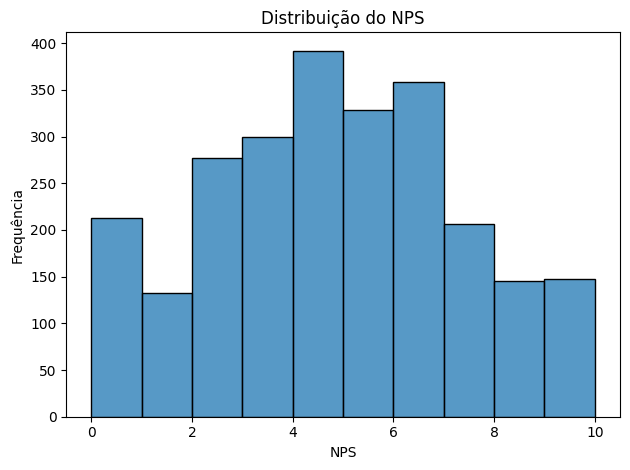

In [58]:
# Distribuição do NPS (Histograma)

sns.histplot(df_nps['nps_score'], bins=10,kde=False)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

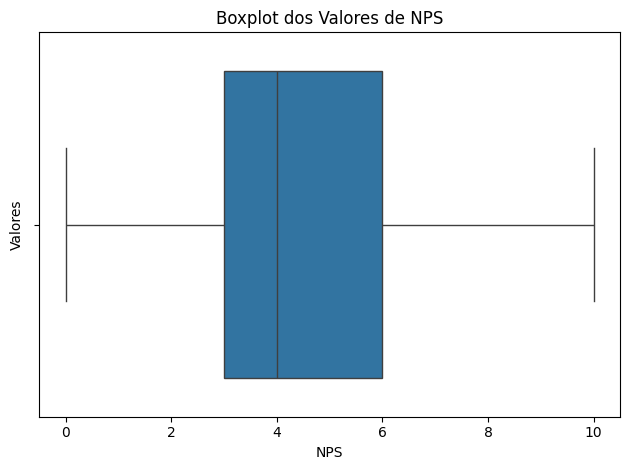

In [59]:
# Boxplot do NPS

sns.boxplot(x=df_nps['nps_score'], data=df_nps)

# Adicionar título e rótulos dos eixos

plt.title('Boxplot dos Valores de NPS')
plt.xlabel('NPS')
plt.ylabel('Valores')
plt.tight_layout()
plt.show()

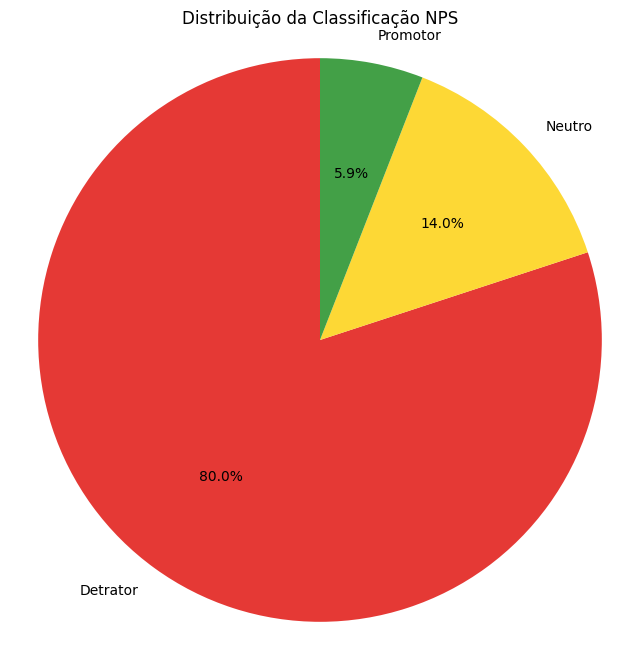

In [60]:
# Classificação do NPS

nps_classification_counts = df_nps['nps_classification'].value_counts()

# Mapeamento de cores

color_map = {
    "Detrator": "#E53935",  # Vermelho
    "Neutro": "#FDD835",    # Amarelo
    "Promotor": "#43A047"   # Verde
}

# Lista de cores na mesma ordem dos índices

colors = [color_map[categoria] for categoria in nps_classification_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(
    nps_classification_counts,
    labels=nps_classification_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Distribuição da Classificação NPS')
plt.axis('equal')
plt.show()

### Conclusão da Sessão - 4.1

A análise inicial do NPS demonstra um cenário de satisfação abaixo do esperado, com predominância de avaliações negativas e baixa participação de promotores. A distribuição das notas sugere que a insatisfação não está restrita a casos isolados, mas reflete problemas recorrentes na jornada do cliente. Além disso, é importante considerar um possível viés comum em pesquisas de satisfação: clientes insatisfeitos tendem a ter maior motivação para responder às pesquisas do que clientes que tiveram uma experiência apenas satisfatória ou neutra. Dessa forma, embora a elevada proporção de detratores seja um sinal de alerta relevante, ela pode representar uma percepção mais intensa dos clientes que enfrentaram problemas. Ainda assim, o volume observado de avaliações negativas indica que existem oportunidades claras de melhoria na experiência oferecida pela empresa. Diante desse cenário, torna-se necessário investigar quais fatores operacionais estão mais associados à queda do NPS, tema explorado nas próximas seções da análise.

## 4.2 Correlações Variáveis Númericas (heatmap)

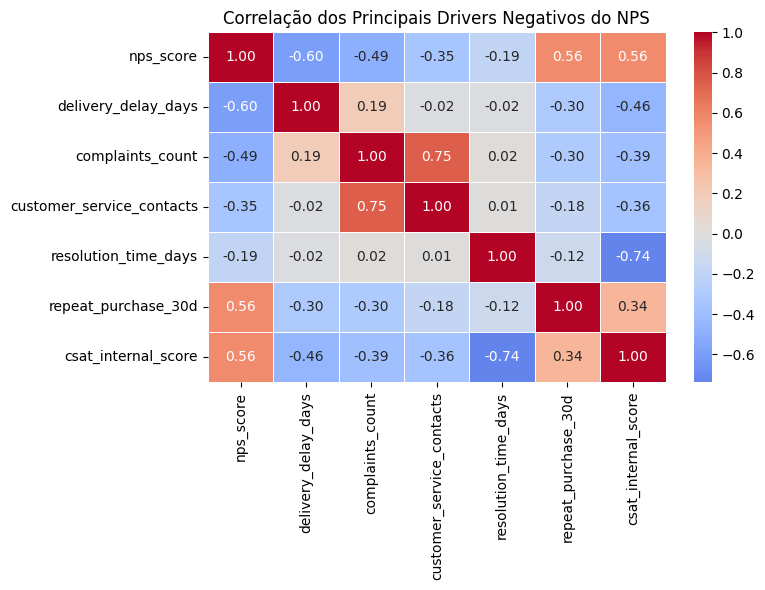

In [61]:
# Selecionando as colunas de interesse para análise de correlação

cols = [
    'nps_score',
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'repeat_purchase_30d',
    'csat_internal_score'
]

# Matriz de correlação
corr = df_nps[cols].corr()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlação dos Principais Drivers Negativos do NPS')
plt.tight_layout()
plt.show()

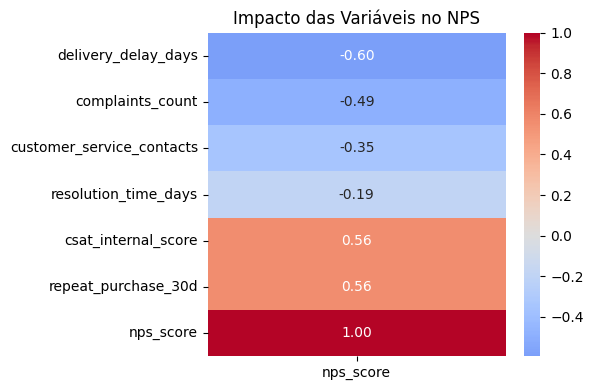

In [62]:
# Heatmap da correlação entre as variáveis e o NPS

variaveis = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'repeat_purchase_30d',
    'csat_internal_score'
]

corr_nps = (
    df_nps[variaveis + ['nps_score']]
    .corr()[['nps_score']]
    .sort_values('nps_score')
)

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_nps,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Impacto das Variáveis no NPS')
plt.tight_layout()
plt.show()

### Conclusão da Sessão - 4.2

A análise de correlação mostra que os principais fatores associados à queda do NPS são os atrasos na entrega, o aumento das reclamações e a necessidade de contato com o atendimento. Os dados apresentam forte consistência entre si, sugerindo uma cadeia de eventos em que problemas logísticos geram reclamações, aumentam a demanda por suporte e impactam negativamente a experiência do cliente. Em contrapartida, a recompra em até 30 dias e o CSAT interno apresentam relação positiva com o NPS, indicando que clientes que enfrentam menos problemas tendem a ficar mais satisfeitos e fiéis à empresa. Embora correlação não represente causalidade, os resultados apontam que melhorias nos processos logísticos e de atendimento podem gerar ganhos significativos na satisfação e na retenção de clientes.

## 4.3 NPS Geral por região

In [63]:
# Nps médio por região

df_nps_regiao = pd.DataFrame(df_nps.groupby('customer_region')[['nps_score']].mean().round(2)).reset_index()

df_nps_regiao.head()

,customer_region,nps_score
0,Centro-Oeste,4.20
1,Nordeste,4.44
2,Norte,4.38
3,Sudeste,4.38
4,Sul,4.47


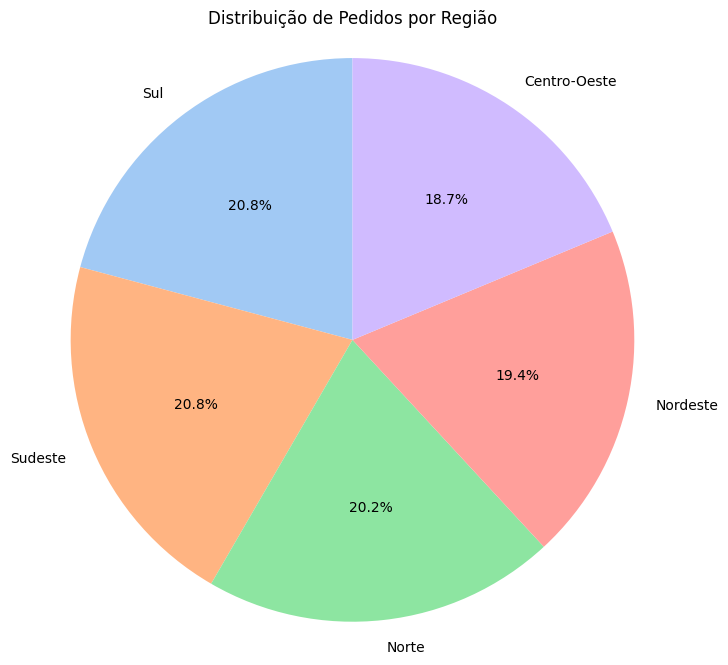

In [64]:
# Classificação do NPS

nps_classification_counts = df_nps['customer_region'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    nps_classification_counts,
    labels=nps_classification_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Distribuição de Pedidos por Região')
plt.axis('equal')
plt.show()

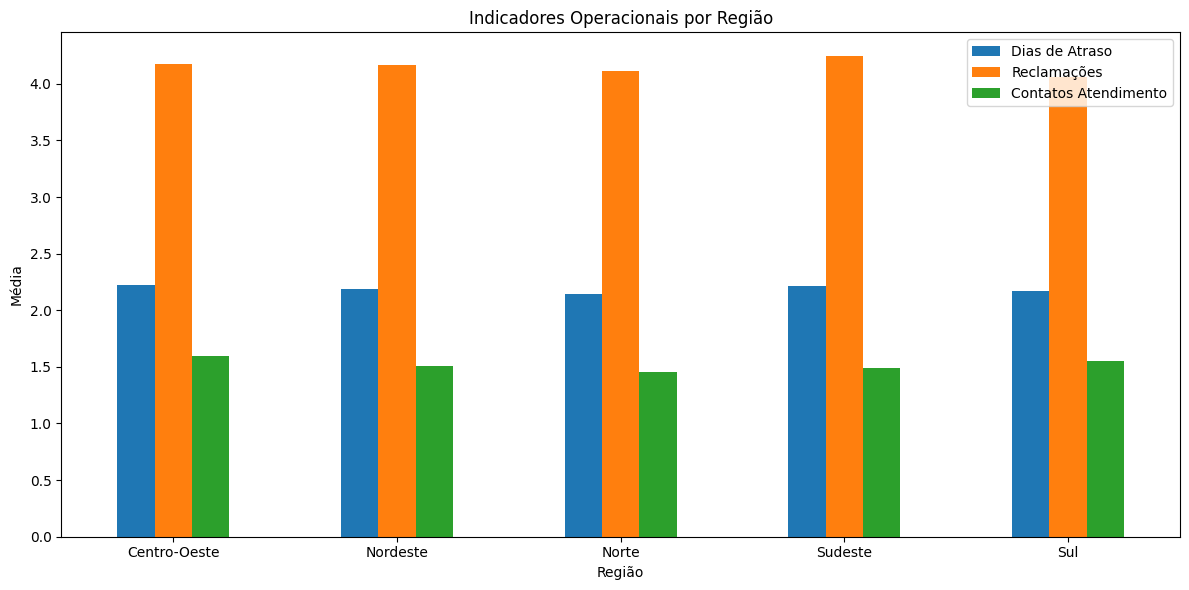

In [65]:
# Visualização de indicadores operacionais por região

comparacao = (
    df_nps.groupby("customer_region")[
        [
            "delivery_delay_days",
            "complaints_count",
            "customer_service_contacts"
        ]
    ]
    .mean()
)

comparacao.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Indicadores Operacionais por Região"
)

plt.xlabel("Região")
plt.ylabel("Média")
plt.xticks(rotation=0)

plt.legend([
    "Dias de Atraso",
    "Reclamações",
    "Contatos Atendimento"
])

plt.tight_layout()
plt.show()

### Conclusão da Sessão - 4.3

Em síntese, a região não se mostrou um fator relevante para explicar a variação do NPS. Os resultados indicam que a satisfação do cliente é muito mais influenciada pela qualidade da experiência operacional do que pela sua localização geográfica.

## 5.1 Preparação dos Dados para Análise

### 5.1.1 Classificação do NPS

In [66]:
# Função para classificar o NPS em Promotor, Neutro e Detrator

def classificar_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df_nps['categoria_nps'] = df_nps['nps_score'].apply(classificar_nps)

### 5.1.2 Criação das faixas de análise

In [67]:
# Atraso na E   ntrega

df_nps['faixa_atraso'] = pd.cut(
    df_nps['delivery_delay_days'],
    bins=[-1,0,2,4,6,100],
    labels=[
        'Sem atraso',
        '1-2 dias',
        '3-4 dias',
        '5-6 dias',
        '7+ dias'
    ]
)

# Quantidade de Reclamações

df_nps['faixa_reclamacoes'] = pd.cut(
    df_nps['complaints_count'],
    bins=[-1,2,4,6,20],
    labels=[
        '0-2',
        '3-4',
        '5-6',
        '7+'
    ]
)

# Contatos com Atendimento

df_nps['faixa_contatos'] = pd.cut(
    df_nps['customer_service_contacts'],
    bins=[-1,1,3,5,20],
    labels=[
        '0-1',
        '2-3',
        '4-5',
        '6+'
    ]
)

# Tempo de Resolução

df_nps['faixa_resolucao'] = pd.cut(
    df_nps['resolution_time_days'],
    bins=[-1,1,3,5,20],
    labels=[
        'Até 1 dia',
        '2-3 dias',
        '4-5 dias',
        '6+ dias'
    ]
)

# Recompra

df_nps['recompra'] = df_nps['repeat_purchase_30d'].map({
    0: 'Não Recomprou',
    1: 'Recomprou'
})


### 5.1.3 Funções Auxiliares para Visualização

In [68]:
def grafico_nps_empilhado(df, coluna, titulo):

    tabela = (
        pd.crosstab(
            df[coluna],
            df['categoria_nps'],
            normalize='index'
        ) * 100
    )

    ordem = ['Detrator', 'Neutro', 'Promotor']

    tabela = tabela.reindex(
        columns=[c for c in ordem if c in tabela.columns]
    )

    cores = {
        'Detrator': '#d62728',  # vermelho
        'Neutro': '#ffbf00',    # amarelo
        'Promotor': '#2ca02c'   # verde
    }

    ax = tabela.plot(
        kind='bar',
        stacked=True,
        figsize=(10,6),
        color=[cores[col] for col in tabela.columns]
    )

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('% de Clientes')
    plt.legend(title='Categoria NPS')
    plt.xticks(rotation=0)

    # Exibir percentual dentro das barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',
            label_type='center',
            fontsize=8,
            color='black'
        )

    plt.tight_layout()
    plt.show()

## 5.2 NPS vs Variáveis Chave

### 5.2.1 NPS vs Dias de Atraso

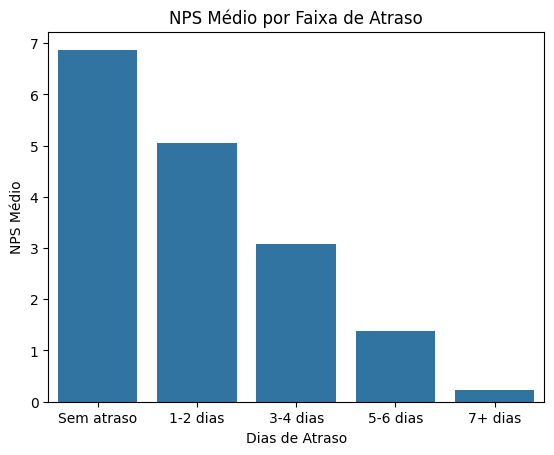

In [69]:
# NPS médio por Dias de Atraso na Entrega

df_nps['delay_group'] = pd.cut(
    df_nps['delivery_delay_days'],
    bins=[-1,0,2,4,6,20],
    labels=[
        'Sem atraso',
        '1-2 dias',
        '3-4 dias',
        '5-6 dias',
        '7+ dias'
    ]
)

resumo = (
    df_nps.groupby('delay_group')
    .agg(
        clientes=('customer_id','count'),
        nps_medio=('nps_score','mean')
    )
    .reset_index()
)

sns.barplot(
    data=resumo,
    x='delay_group',
    y='nps_medio'
)

plt.title('NPS Médio por Faixa de Atraso')
plt.xlabel('Dias de Atraso')
plt.ylabel('NPS Médio')
plt.show()

#print(resumo)

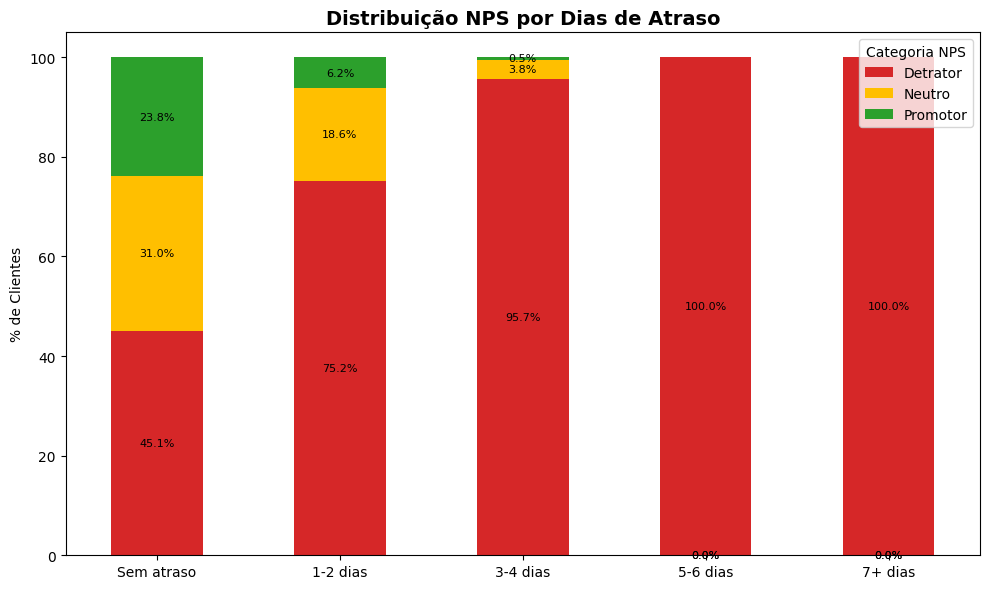

In [70]:
# Gráfico de barras empilhadas do NPS por Dias de Atraso na Entrega

grafico_nps_empilhado(
    df_nps,
    'faixa_atraso',
    'Distribuição NPS por Dias de Atraso'
)

### 5.2.2 NPS vs Quantidade de Reclamações

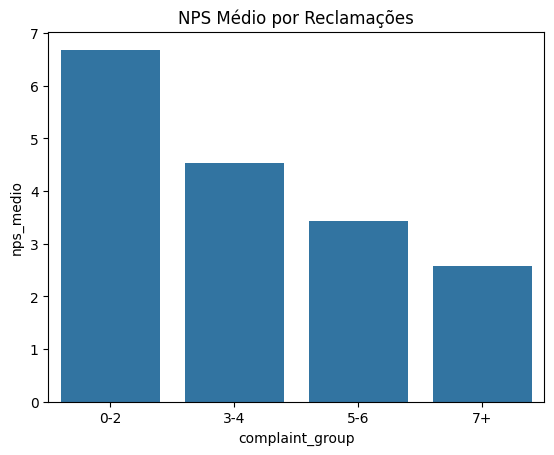

In [71]:
# NPS médio por Quantidade de Reclamações

df_nps['complaint_group'] = pd.cut(
    df_nps['complaints_count'],
    bins=[-1,2,4,6,20],
    labels=[
        '0-2',
        '3-4',
        '5-6',
        '7+'
    ]
)

resumo = (
    df_nps.groupby('complaint_group')
    .agg(
        clientes=('customer_id','count'),
        nps_medio=('nps_score','mean')
    )
    .reset_index()
)

sns.barplot(
    data=resumo,
    x='complaint_group',
    y='nps_medio'
)

plt.title('NPS Médio por Reclamações')
plt.show()

#print(resumo)

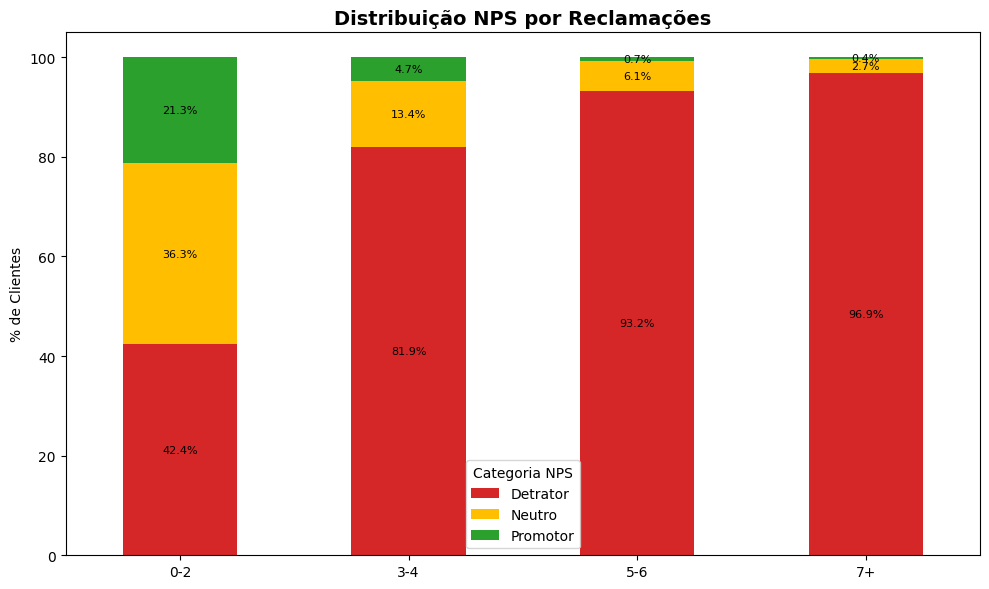

In [72]:
# Gráfico de barras empilhadas do NPS por quantidade de Reclamações

grafico_nps_empilhado(
    df_nps,
    'faixa_reclamacoes',
    'Distribuição NPS por Reclamações'
)

### 5.2.3 NPS vs Quantidade de Contatos com o Atendimento

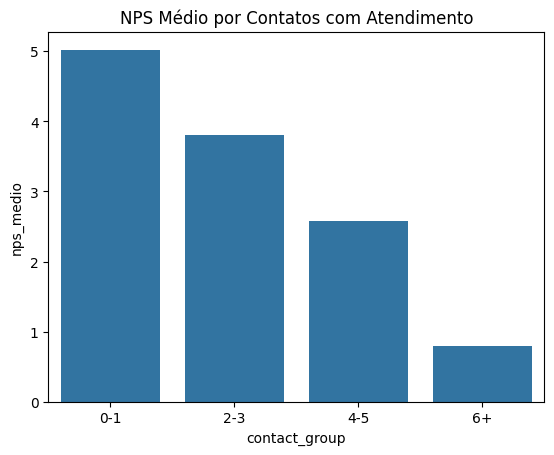

In [73]:
df_nps['contact_group'] = pd.cut(
    df_nps['customer_service_contacts'],
    bins=[-1,1,3,5,20],
    labels=[
        '0-1',
        '2-3',
        '4-5',
        '6+'
    ]
)

resumo = (
    df_nps.groupby('contact_group')
    .agg(
        clientes=('customer_id','count'),
        nps_medio=('nps_score','mean')
    )
    .reset_index()
)

sns.barplot(
    data=resumo,
    x='contact_group',
    y='nps_medio'
)

plt.title('NPS Médio por Contatos com Atendimento')
plt.show()

#print(resumo)

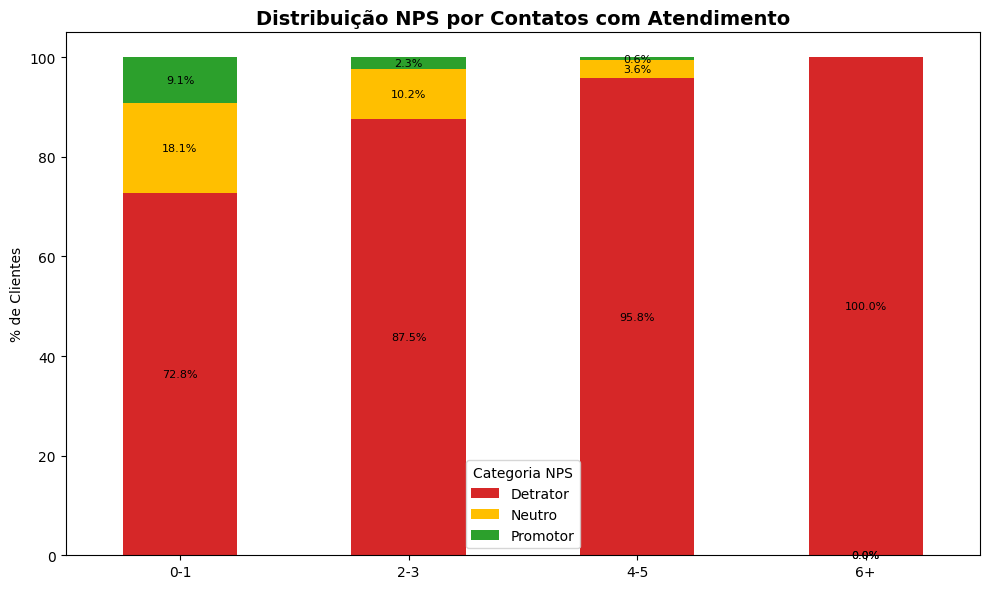

In [74]:
# Gráfico de barras empilhadas do NPS por quantidade de Contatos com Atendimento

grafico_nps_empilhado(
    df_nps,
    'faixa_contatos',
    'Distribuição NPS por Contatos com Atendimento'
)

### 5.2.4 NPS vs Tempo de Resolução

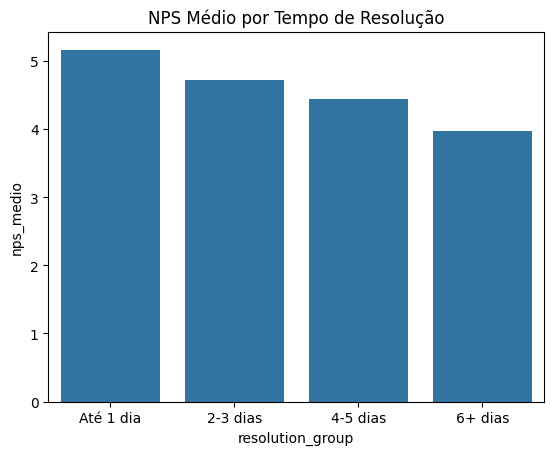

In [75]:
df_nps['resolution_group'] = pd.cut(
    df_nps['resolution_time_days'],
    bins=[-1,1,3,5,20],
    labels=[
        'Até 1 dia',
        '2-3 dias',
        '4-5 dias',
        '6+ dias'
    ]
)

resumo = (
    df_nps.groupby('resolution_group')
    .agg(
        clientes=('customer_id','count'),
        nps_medio=('nps_score','mean')
    )
    .reset_index()
)

sns.barplot(
    data=resumo,
    x='resolution_group',
    y='nps_medio'
)

plt.title('NPS Médio por Tempo de Resolução')
plt.show()

#print(resumo)

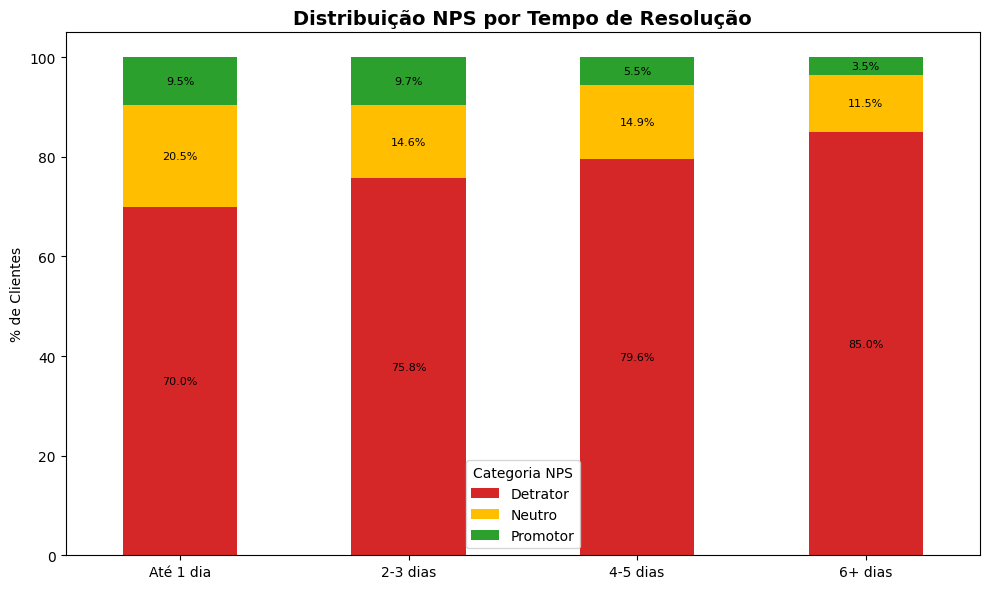

In [76]:
# Gráfico de barras empilhadas do NPS por quantidade de Contatos com Atendimento

grafico_nps_empilhado(
    df_nps,
    'faixa_resolucao',
    'Distribuição NPS por Tempo de Resolução'
)

### 5.2.5 NPS vs Recompra em 30 dias

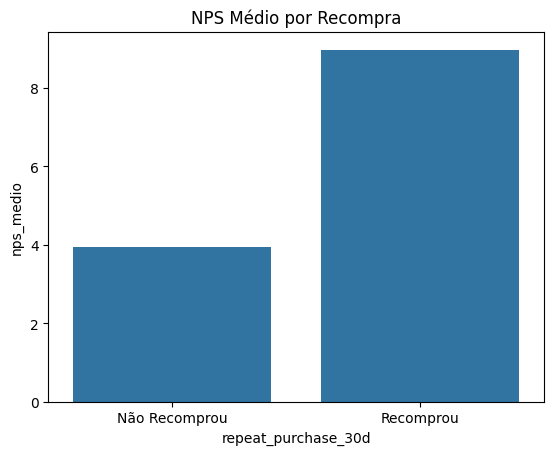

In [77]:
resumo = (
    df_nps.groupby('repeat_purchase_30d')
    .agg(
        clientes=('customer_id','count'),
        nps_medio=('nps_score','mean')
    )
    .reset_index()
)

resumo['repeat_purchase_30d'] = resumo[
    'repeat_purchase_30d'
].map({
    0:'Não Recomprou',
    1:'Recomprou'
})

sns.barplot(
    data=resumo,
    x='repeat_purchase_30d',
    y='nps_medio'
)

plt.title('NPS Médio por Recompra')
plt.show()

#print(resumo)

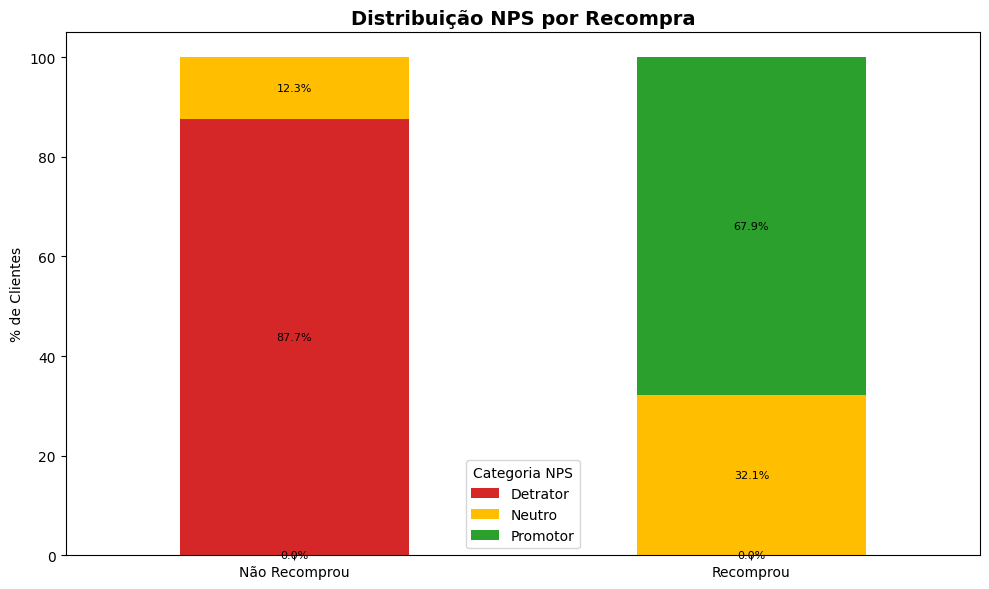

In [78]:
# Gráfico de barras empilhadas do NPS por clientes que Recompraram ou não

grafico_nps_empilhado(
    df_nps,
    'recompra',
    'Distribuição NPS por Recompra'
)

##

# 6. Conclusão Geral

In [79]:
# Cores para os gráficos

VERMELHO = "#D9534F"
AMARELO = "#F0AD4E"
VERDE = "#5CB85C"
AZUL = "#5B8FF9"

## 6.1 Quais fatores parecem mais críticos para a satisfação?

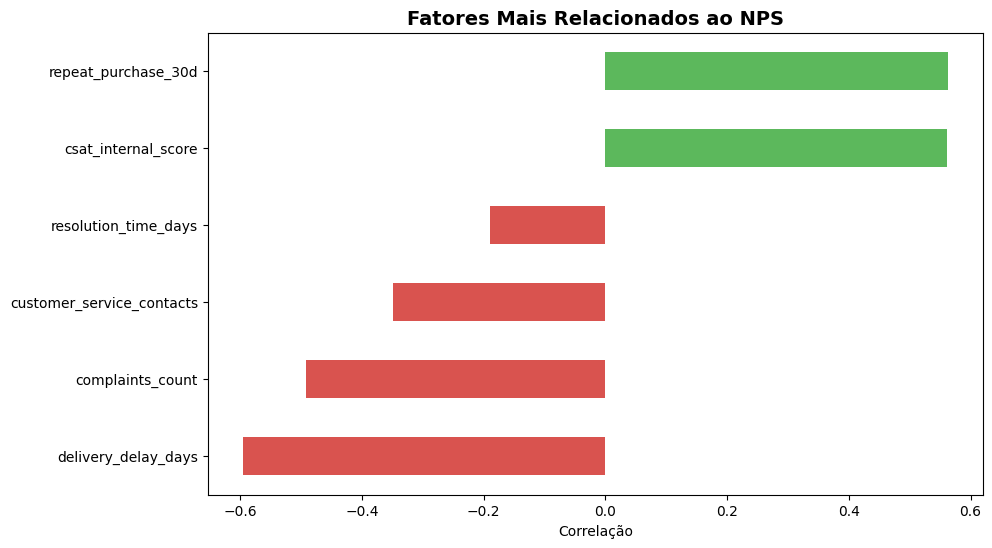

In [80]:
# Gráfico de barras horizontais da correlação entre as variáveis e o NPS

corr_nps = (
    df_nps[
        [
            'delivery_delay_days',
            'complaints_count',
            'customer_service_contacts',
            'resolution_time_days',
            'repeat_purchase_30d',
            'csat_internal_score',
            'nps_score'
        ]
    ]
    .corr()['nps_score']
    .drop('nps_score')
    .sort_values()
)

plt.figure(figsize=(10,6))

corr_nps.plot(
    kind='barh',
    color=[
        VERMELHO if x < 0 else VERDE
        for x in corr_nps
    ]
)

plt.title(
    'Fatores Mais Relacionados ao NPS',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Correlação')
plt.show()

### Conclusão da Sessão - 6.1

Os fatores mais críticos para a satisfação são atraso na entrega, quantidade de reclamações e necessidade de contato com o atendimento. Os dados mostram que, à medida que esses indicadores aumentam, a satisfação tende a diminuir. Por outro lado, clientes que realizam uma nova compra e apresentam melhores avaliações internas de satisfação tendem a registrar notas mais altas de NPS.

## 6.2 O que mais gera detratores?

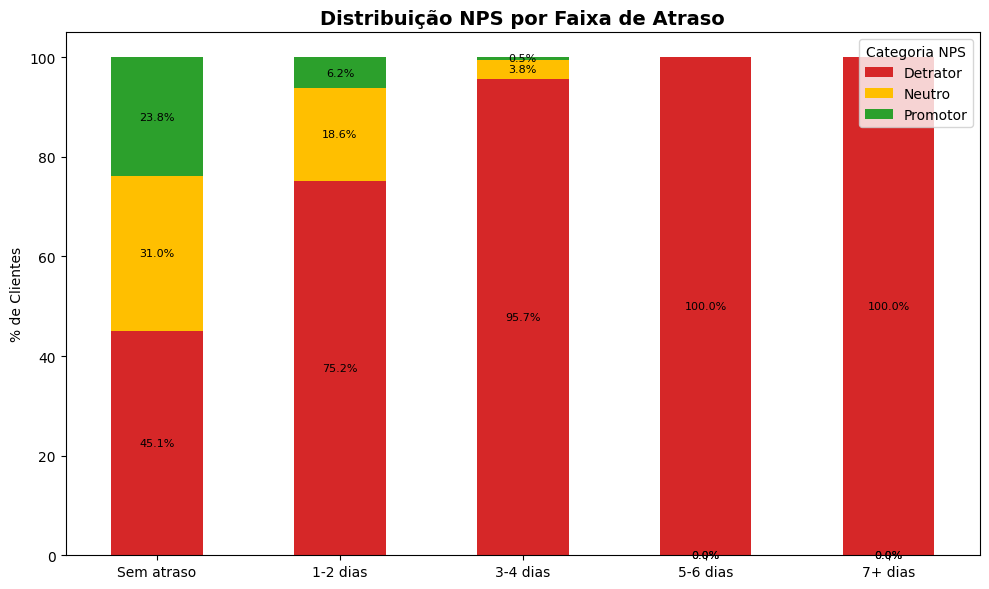

In [81]:
grafico_nps_empilhado(
    df_nps,
    'faixa_atraso',
    'Distribuição NPS por Faixa de Atraso'
)

### Conclusão da Sessão - 6.2

O principal gerador de detratores parece ser o atraso na entrega. À medida que o atraso aumenta, a proporção de clientes detratores cresce de forma significativa. Esse comportamento sugere que o atraso funciona como um gatilho para outros problemas, como reclamações e necessidade de contato com o suporte.


## 6.3 Existe algum “ponto de ruptura” na experiência do cliente?


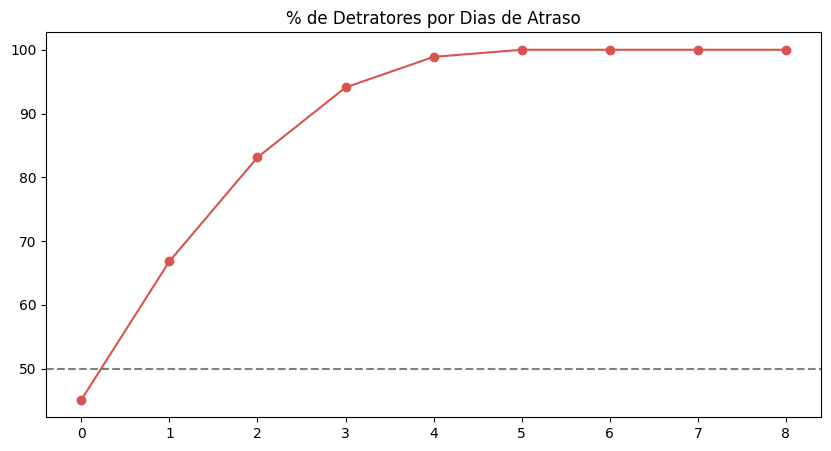

In [82]:
detratores = (
    df_nps.groupby('delivery_delay_days')
          ['categoria_nps']
          .apply(
              lambda x:
              (x == 'Detrator').mean()*100
          )
          .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    detratores['delivery_delay_days'],
    detratores['categoria_nps'],
    marker='o',
    color=VERMELHO
)

plt.axhline(
    50,
    linestyle='--',
    color='gray'
)

plt.title(
    '% de Detratores por Dias de Atraso'
)

plt.show()

### Conclusão da Sessão - 6.3

Os dados indicam a existência de um ponto de ruptura na experiência do cliente. Até pequenos atrasos, a satisfação ainda se mantém relativamente estável. Entretanto, a partir de aproximadamente 4 dias de atraso, observa-se um crescimento acelerado da proporção de detratores.

## 6.4  Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

<Axes: >

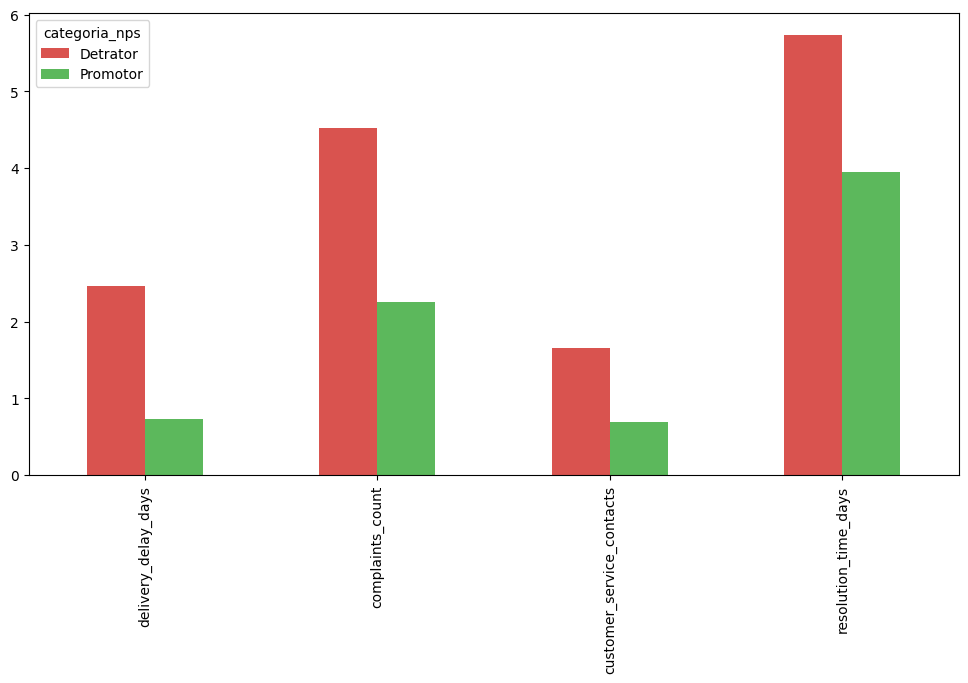

In [83]:
comparacao = (
    df_nps[
        df_nps['categoria_nps']
        .isin(
            ['Promotor','Detrator']
        )
    ]
    .groupby('categoria_nps')
    [
        [
            'delivery_delay_days',
            'complaints_count',
            'customer_service_contacts',
            'resolution_time_days'
        ]
    ]
    .mean()
    .T
)

comparacao.plot(
    kind='bar',
    figsize=(12,6),
    color=[VERMELHO, VERDE]
)

### Conclusão da Sessão - 6.3

#### Explicação

**Cliente com NPS alto**

Normalmente apresenta:

- Entrega dentro do prazo;
- Poucas reclamações;
- Pouco contato com atendimento;
- Resolução rápida de problemas;
- Recompra em até 30 dias.

**Cliente com NPS baixo**

Normalmente apresenta:

- Entregas atrasadas;
- Muitas reclamações;
- Diversos contatos com atendimento;
- Resolução lenta;
- Não realiza recompra.

### Conclusão Final

A análise indica que a principal fonte de insatisfação está relacionada a falhas operacionais, especialmente atrasos na entrega, reclamações e necessidade de suporte. Os dados sugerem uma jornada de insatisfação em que atrasos geram reclamações, aumentam os contatos com o atendimento e elevam o tempo de resolução, culminando em avaliações negativas. Por outro lado, clientes que passam por uma experiência sem atritos apresentam maior probabilidade de recompra e de recomendação da empresa. Dessa forma, iniciativas voltadas à melhoria dos processos logísticos e de atendimento possuem o maior potencial de impacto sobre o NPS e sobre a fidelização dos clientes.